In [1]:
import numpy as np

from matplotlib import pyplot as plt

import cv2

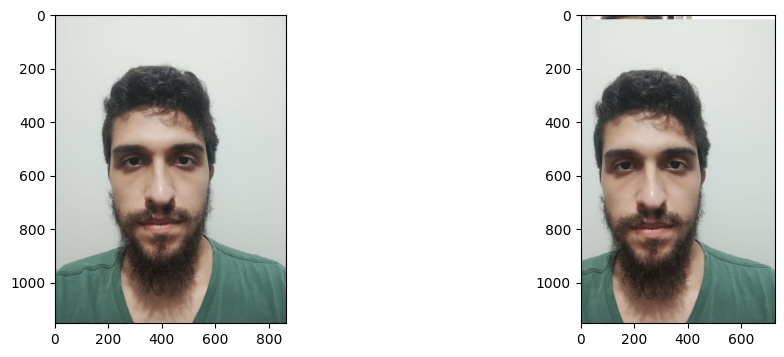

In [28]:
pic1 = cv2.imread("Foto.jpeg")
pic1 = cv2.cvtColor(pic1, cv2.COLOR_BGR2RGB)

pic2 = cv2.imread("test.png")
pic2 = cv2.cvtColor(pic2, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

ax[0].imshow(pic1)
ax[1].imshow(pic2)

plt.show()

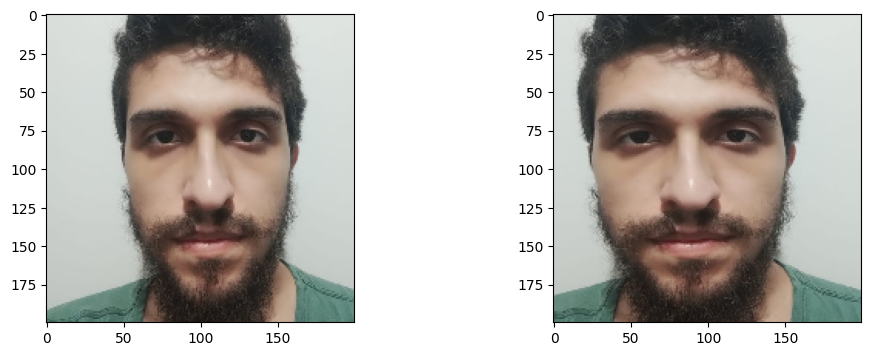

In [22]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

ax[0].imshow( process_and_crop_face(pic1) )
ax[1].imshow( process_and_crop_face(pic2) )

plt.show()

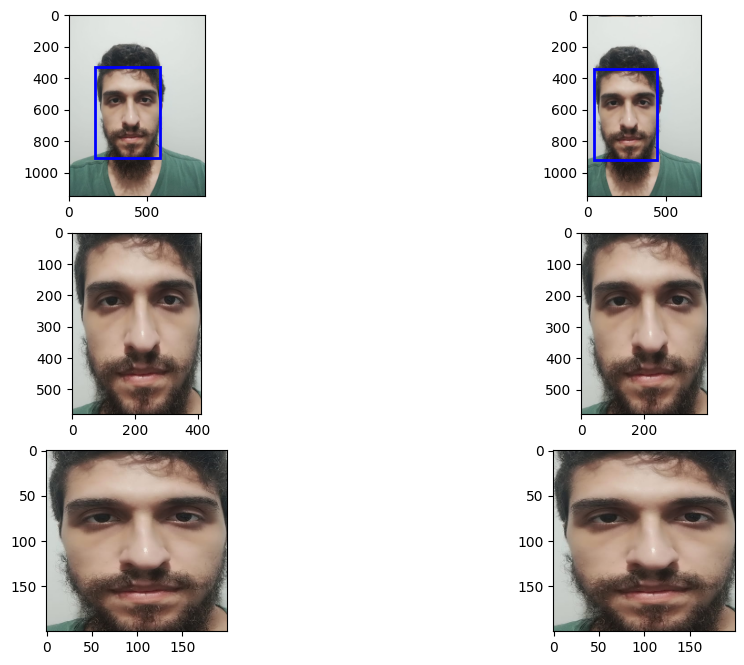

In [45]:
import matplotlib.patches as patches

resultados1 = detector.detect_faces(pic1)
resultados2 = detector.detect_faces(pic2)
    
if len(resultados1) == 0:
    raise("Sem rosto!")  # Nenhum rosto detectado

if len(resultados2) == 0:
    raise("Sem rosto!")  # Nenhum rosto detectado
    
# Pega o rosto com a maior probabilidade (maior confiança)
rosto_principal1 = max( resultados1, key=lambda b: b['confidence'] )
x1, y1, width1, height1 = rosto_principal1['box']

rosto_principal2 = max( resultados2, key=lambda b: b['confidence'] )
x2, y2, width2, height2 = rosto_principal2['box']

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,8))

rect1 = patches.Rectangle((x1, y1), width1, height1, linewidth=2, edgecolor='blue', facecolor='none')
rect2 = patches.Rectangle((x2, y2), width2, height2, linewidth=2, edgecolor='blue', facecolor='none')

pic_crop1 = pic1[y1:(y1+height1), x1:(x1+width1)]
pic_crop2 = pic2[y2:(y2+height2), x2:(x2+width2)]

ax[0,0].imshow( pic1 )
ax[0,0].add_patch(rect1)

ax[0,1].imshow( pic2 )
ax[0,1].add_patch(rect2)

ax[1,0].imshow( pic_crop1 )
ax[1,1].imshow( pic_crop2 )

pic_resize1 = cv2.resize(pic_crop1, (200, 200))
pic_resize2 = cv2.resize(pic_crop2, (200, 200))

ax[2,0].imshow( pic_resize1 )
ax[2,1].imshow( pic_resize2 )

save_pic1 = cv2.cvtColor(pic_resize1, cv2.COLOR_RGB2BGR)
save_pic2 = cv2.cvtColor(pic_resize2, cv2.COLOR_RGB2BGR)

cv2.imwrite("test1.jpg", save_pic1)
cv2.imwrite("test2.jpg", save_pic2)

plt.show()

In [19]:
import cv2
import numpy as np
from mtcnn import MTCNN

# INICIALIZE O DETECTOR GLOBALMENTE (Fora da função predict!)
# Isso garante que a rede do MTCNN seja carregada apenas uma vez na memória
detector = MTCNN()

def process_and_crop_face(img):
    
    # 1. Detecta os rostos na imagem
    # O MTCNN retorna uma lista de dicionários, cada um com 'box', 'confidence', etc.
    resultados = detector.detect_faces(img)
    
    if len(resultados) == 0:
        return None  # Nenhum rosto detectado
        
    # Pega o rosto com a maior probabilidade (maior confiança)
    rosto_principal = max( resultados, key=lambda b: b['confidence'] )
    x, y, width, height = rosto_principal['box']
    
    # O MTCNN às vezes retorna coordenadas negativas se o rosto estiver cortado na borda
    x, y = abs(x), abs(y)
    
    # 2. Lógica para transformar o retângulo em um quadrado (Estilo UTKFace)
    # Encontra o centro do rosto
    centro_x = x + width / 2
    centro_y = y + height / 2
    
    # Pega o maior lado para garantir que o rosto inteiro caiba
    lado_maximo = max(width, height)
    
    # Adiciona uma margem de 20% (UTKFace geralmente inclui testa e queixo completo)
    margem = 1.2
    tamanho_quadrado = int(lado_maximo * margem)
    
    # Calcula as novas coordenadas (top-left)
    x_novo = int(centro_x - tamanho_quadrado / 2)
    y_novo = int(centro_y - tamanho_quadrado / 2)
    
    # Garante que o quadrado não ultrapasse as bordas reais da foto original
    y1 = max(0, y_novo)
    y2 = min(img.shape[0], y_novo + tamanho_quadrado)
    x1 = max(0, x_novo)
    x2 = min(img.shape[1], x_novo + tamanho_quadrado)
    
    # 3. Recorta o rosto
    rosto_recortado = img[y1:y2, x1:x2]
    
    # Se o corte falhar por algum motivo de borda, previne o erro
    if rosto_recortado.size == 0:
        return None
        
    # 4. Redimensiona para os 200x200 exigidos
    rosto_redimensionado = cv2.resize(rosto_recortado, (200, 200))
    
    # 5. Normalização [-1, 1] da MobileNetV2
    # rosto_normalizado = rosto_redimensionado.astype('float32')
    # rosto_normalizado = (rosto_normalizado / 127.5) - 1.0
    
    # Retorna com a dimensão do batch (1, 200, 200, 3)
    return rosto_redimensionado